# Libraries

In [2]:
pip install bs4


   ---------------------------------------- 3/3 [bs4]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import requests 
from bs4 import BeautifulSoup

# Web Scraping

In [ ]:
req = requests.get("https://sol.sbc.org.br/busca/index.php/integrada/results?query=&archiveIds%5B%5D=1&archiveIds%5B%5D=2&archiveIds%5B%5D=3&isAdvanced=1&field-10%5B%5D=por&field-10%5B%5D=eng&searchPage=1#records")
if  req.status_code == 200:
    print("Conexão bem sucedida!")

In [ ]:
soup = BeautifulSoup(req.content, 'html.parser')
#print(soup.prettify())

Obtendo a última página

In [ ]:
pagination_div = soup.find("div", class_="pagination_results")

for a in pagination_div.find_all("a", href=True):
    link = a["href"]

print(link)    

In [ ]:
start_delimiter = "searchPage="
end_delimiter = "#records"


start_index = link.find(start_delimiter)
if start_index != -1:
    start_index += len(start_delimiter)
    
    end_index = link.find(end_delimiter, start_index)
    
    if end_index != -1:
        last_page = link[start_index:end_index]
        print(f"Última Página: {last_page}")
    else:
        print("Delimitador final não encontrado.")
else:
    print("Delimitador inicial não encontrado.")



Obtendo Informações dos artigos

In [ ]:
list_page = []

df = pd.DataFrame(columns=['Category', 'Title', 'URL_Title', 'Authors', 'Event', 'Date'])

for page in range(1, int(last_page) + 1):
    
    url = f"https://sol.sbc.org.br/busca/index.php/integrada/results?query=&archiveIds%5B%5D=1&archiveIds%5B%5D=2&archiveIds%5B%5D=3&isAdvanced=1&field-10%5B%5D=por&field-10%5B%5D=eng&searchPage={page}"
    print("Página", page, " - ", url)
    
    req = requests.get(url)
    if  req.status_code == 200:
        print("Conexão bem sucedida!")
    
    soup = BeautifulSoup(req.content, 'html.parser')
    #print(soup.prettify())

    list_category = soup.find_all(class_="archive_title")
    list_title = soup.find_all(class_="title")
    list_url_title = soup.find_all(class_="record_title")
    list_authors = soup.find_all(class_="author")
    list_event = soup.find_all(class_="archive_serie")
    list_date = soup.find_all(class_="list_record_date")
 
    if len(list_title) != 26:
        list_page.append(page)
        print("Página com menos de 25 registros:", page)


    for category, title, url_title, authors, event, date in zip(list_category, list_title, list_url_title, list_authors, list_event, list_date):
        category = category.get_text()
        title = title.get_text()
        url_title = url_title.get('href')
        authors = authors.get_text()
        event = event.get_text()    
        date = date.get_text(strip=True)
    
        df = df._append({'Category': category, 'Title': title, 'URL_Title': url_title, 'Authors': authors, 'Event': event, 'Date': date}, ignore_index=True)

In [ ]:
df.head()

In [ ]:
# Mantendo apenas Anais de Evento e Periódicos
df = df[df['Category'].str.contains("ANAIS DE EVENTO|PERIÓDICOS", regex=True, na=False)]

In [ ]:
df['Box'] = None

df.loc[0:3999, 'Box'] = "Caixa 1"
df.loc[4000:7999, 'Box'] = "Caixa 2"
df.loc[8000:11999, 'Box'] = "Caixa 3"
df.loc[12000:15999, 'Box'] = "Caixa 4"
df.loc[16000:19999, 'Box'] = "Caixa 5"
df.loc[20000:23999, 'Box'] = "Caixa 6"
df.loc[24000:27999, 'Box'] = "Caixa 7"
df.loc[28000:31999, 'Box'] = "Caixa 8"
df.loc[32000:, 'Box'] = "Caixa 9"

In [ ]:
df.to_csv('sol_sbc_eventos_periodicos.csv', index=False)

Obtendo os metadados (dentre eles, o resumo) o de cada artigo

In [ ]:
df = pd.read_csv('sol_sbc_eventos_periodicos.csv')

df_box = df[df['Box'] == "Caixa 1"]
df_box.info()

In [ ]:
df_papers = pd.DataFrame(columns=['Event', 'Authors', 'Title', 'Abstract', 'Keywords', 'Publisher', 'URL_Paper', 'Date'])

paper_number = 1

for url in df_box['URL_Title']:
    
    print(url)
    print("Paper number:", paper_number)
    req = requests.get(url)

    soup = BeautifulSoup(req.content, 'html.parser')
    soup.prettify()

    try:
        event = soup.find(class_="cmp_breadcrumbs")
        event = event.get_text()
        #print(event)
    except AttributeError:
        event = "No event available"
    
    try:
        list_authors = soup.find(class_="item authors")
        list_authors = list_authors.get_text(strip=True)
        #print(list_authors)
    except AttributeError:
        list_authors = "No authors available"
    
    try:
        title = soup.find(class_="page_title")
        title = title.get_text(strip=True)
        #print(title)
    except AttributeError:
        title = "No title available"

    try:
        abstract = soup.find(class_="item abstract")
        abstract = abstract.get_text(strip=True)
    except AttributeError:
        abstract = "No abstract available"
        #print(abstract)

    try:
        keywords = soup.find(class_="item keywords")
        keywords = keywords.get_text(strip=True)
    except AttributeError:
        keywords = "No keywords available"
    #print(keywords)

    try:
        url_paper = (soup.find(class_="obj_galley_link pdf") or soup.find(class_="obj_galley_link file"))
        publisher = url_paper.get_text(strip=True)
        #print(publisher)

        url_paper = url_paper.get('href')
        #print(url_paper)
    except AttributeError:
        publisher = "No publisher available"
        url_paper = "No URL available"

    try:
        date = soup.find(class_="item published")
        date = date.get_text(strip=True)
    except AttributeError:
        date = "No date available"
        #print(date)
    
    paper_number += 1

    df_papers = df_papers._append({'Event': event, 
                     'Authors': list_authors, 
                     'Title': title, 
                     'Abstract' : abstract, 
                     'Keywords' : keywords, 
                     'Publisher' : publisher, 
                     'URL_Paper' : url_paper,
                     'Date': date}, 
                     
                     ignore_index=True)

df_papers.to_csv('df_papers_caixa_1.csv', index=True)

In [ ]:
# Concatenar os Arquivos CSV e gerar o CSV final com todos os metadados
import pandas as pd
import os
import glob

pasta = "C:\\Users\\Thiago Lobo\\Projeto-Mestrado\\Experimentos"
caminhos_arquivos = glob.glob(os.path.join(pasta, "*.csv"))

lista_df = []

for caminho_arquivo in caminhos_arquivos:
    df_individual = pd.read_csv(caminho_arquivo)
    lista_df.append(df_individual)

df_final = pd.concat(lista_df, ignore_index=True)

df_final.to_csv("metadados-sol-lib.csv", index=False) 

# Mesclagem de Bases

Pré-processamento de dados da Primeira Base - sol_sbc_eventos_periodicos

In [25]:
df_sol_sbc_eventos_periodicos = pd.read_csv('sol_sbc_eventos_periodicos.csv')

df_sol_sbc_eventos_periodicos['Title'] = df_sol_sbc_eventos_periodicos['Title'].str.strip()

titulos_remover = ['Apresentação', 'Apresentação e Organização', 'Cover and Frontmatter']

# Filtrando o DataFrame
df_sol_sbc_eventos_periodicos = df_sol_sbc_eventos_periodicos[~df_sol_sbc_eventos_periodicos['Title'].isin(titulos_remover)]

df_sol_sbc_eventos_periodicos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34103 entries, 1 to 34163
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Category   34103 non-null  object
 1   Title      34103 non-null  object
 2   URL_Title  34103 non-null  object
 3   Authors    34103 non-null  object
 4   Event      34103 non-null  object
 5   Date       34103 non-null  object
 6   Box        34103 non-null  object
dtypes: object(7)
memory usage: 2.1+ MB


In [26]:
# Encontrar todas as linhas onde Title está duplicado
duplicados_sol_sbc_eventos = df_sol_sbc_eventos_periodicos[df_sol_sbc_eventos_periodicos.duplicated(subset='Title', keep=False)]

duplicados_sol_sbc_eventos.info()

duplicados_sol_sbc_eventos.to_csv("duplicados_sbc_eventos_periodicos.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 723 entries, 143 to 34156
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Category   723 non-null    object
 1   Title      723 non-null    object
 2   URL_Title  723 non-null    object
 3   Authors    723 non-null    object
 4   Event      723 non-null    object
 5   Date       723 non-null    object
 6   Box        723 non-null    object
dtypes: object(7)
memory usage: 45.2+ KB


Pré-processamento de dados da Segunda Base - metadados-sol-lib

In [ ]:
import re

df_metadados_sol_lib = pd.read_csv('metadados-sol-lib.csv') # arquivo com os Abstracts

df_metadados_sol_lib['Abstract'] = (
    df_metadados_sol_lib['Abstract']
    .fillna('')
    .str.strip()
    .str.replace(r'^(Resumo|Abstract)\s*:?[\s\-]*', '', regex=True)
)

df_metadados_sol_lib['Keywords'] = (
    df_metadados_sol_lib['Keywords']
    .fillna('')
    .str.strip()
    .str.replace(r'^(Palavras-chave|Keywords)\s*:?[\s\-]*', '', regex=True)
    .str.split(',')
)

df_metadados_sol_lib['Keywords'] = df_metadados_sol_lib['Keywords'].apply(
    lambda lista: [re.sub(r'\s+', ' ', k).strip() for k in lista if k.strip()]
)

df_metadados_sol_lib['Date'] = (
    df_metadados_sol_lib['Date']
    .fillna('')
    .str.strip()
    .str.replace(r'^(Publicado|Published)\s*:?[\s\-]*', '', regex=True)
)

# Remoção de entradas com título "Aprensentação ou Apresentação e Organização
titulos_remover = ['Apresentação', 'Apresentação e Organização']

# Filtrando o DataFrame
df_metadados_sol_lib = df_metadados_sol_lib[~df_metadados_sol_lib['Title'].isin(titulos_remover)]

df_metadados_sol_lib.info()

df_metadados_sol_lib.to_csv('metadados-sol-lib-limpo.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 34093 entries, 1 to 34163
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  34093 non-null  int64 
 1   Event       34093 non-null  object
 2   Authors     34093 non-null  object
 3   Title       34093 non-null  object
 4   Abstract    34093 non-null  object
 5   Keywords    34093 non-null  object
 6   Publisher   34093 non-null  object
 7   URL_Paper   34093 non-null  object
 8   Date        34093 non-null  object
dtypes: int64(1), object(8)
memory usage: 2.6+ MB


In [ ]:
df_metadados_sol_lib = pd.read_csv('metadados-sol-lib-limpo-ajustes-manuais.csv')

# Encontrar todas as linhas onde Title está duplicado
duplicados_metadados_sol_lib = df_metadados_sol_lib[df_metadados_sol_lib.duplicated(subset='Title', keep=False)]

duplicados_metadados_sol_lib.info()

duplicados_metadados_sol_lib.to_csv("duplicados_metadados_sol_lib.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 612 entries, 142 to 34052
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  612 non-null    int64 
 1   Event       612 non-null    object
 2   Authors     612 non-null    object
 3   Title       612 non-null    object
 4   Abstract    612 non-null    object
 5   Keywords    612 non-null    object
 6   Publisher   612 non-null    object
 7   URL_Paper   612 non-null    object
 8   Date        612 non-null    object
dtypes: int64(1), object(8)
memory usage: 47.8+ KB


Mesclando as Bases pela Coluna Title

In [34]:
cols_df1 = ['Title', 'Category', 'URL_Title', 'Authors', 'Event', 'Date', 'Box']
cols_df2 = ['Title', 'Abstract', 'Keywords', 'Publisher', 'URL_Paper']

df1_unique = df_sol_sbc_eventos_periodicos.drop_duplicates(subset='Title')[cols_df1]
df2_unique = df_metadados_sol_lib.drop_duplicates(subset='Title')[cols_df2]

df_merged = pd.merge(df1_unique, df2_unique, on='Title', how='inner')  # ou 'inner' se quiser só títulos que existem nos dois
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29678 entries, 0 to 29677
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      29678 non-null  object
 1   Category   29678 non-null  object
 2   URL_Title  29678 non-null  object
 3   Authors    29678 non-null  object
 4   Event      29678 non-null  object
 5   Date       29678 non-null  object
 6   Box        29678 non-null  object
 7   Abstract   29677 non-null  object
 8   Keywords   29678 non-null  object
 9   Publisher  29678 non-null  object
 10  URL_Paper  29678 non-null  object
dtypes: object(11)
memory usage: 2.5+ MB


In [ ]:
#df1_unique = df_sol_sbc_eventos_periodicos.drop_duplicates(subset='Title')[cols_df1]
#df2_unique = df_metadados_sol_lib.drop_duplicates(subset='Title')[cols_df2]

In [ ]:
df_merged.to_csv("metadados_completos_sol_sbc.csv", index=False)

Tratamento Finais da Base Mesclada

In [10]:
pip install langdetect

Note: you may need to restart the kernel to use updated packages.


In [11]:
import  pandas as pd
import numpy as np
from langdetect import detect

In [37]:
# Convertendo a coluna 'Date' para o formato datetime

df_merged = df_merged.dropna(subset=['Abstract'])
df_merged['Date'] = pd.to_datetime(df_merged['Date'])
df_merged['Abstract_Language'] = df_merged['Abstract'].apply(lambda x: detect(x))
df_merged['Title_Language'] = df_merged['Title'].apply(lambda x: detect(x))

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29677 entries, 0 to 29677
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              29677 non-null  object        
 1   Category           29677 non-null  object        
 2   URL_Title          29677 non-null  object        
 3   Authors            29677 non-null  object        
 4   Event              29677 non-null  object        
 5   Date               29677 non-null  datetime64[ns]
 6   Box                29677 non-null  object        
 7   Abstract           29677 non-null  object        
 8   Keywords           29677 non-null  object        
 9   Publisher          29677 non-null  object        
 10  URL_Paper          29677 non-null  object        
 11  Abstract_Language  29677 non-null  object        
 12  Title_Language     29677 non-null  object        
dtypes: datetime64[ns](1), object(12)
memory usage: 3.2+ MB


In [38]:
df__merged_portuguese = df_merged[df_merged['Abstract_Language'] == 'pt']

df__merged_portuguese.info()
df__merged_portuguese.to_csv("metadados_completos_sol_sbc_portugues.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
Index: 17490 entries, 248 to 29677
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Title              17490 non-null  object        
 1   Category           17490 non-null  object        
 2   URL_Title          17490 non-null  object        
 3   Authors            17490 non-null  object        
 4   Event              17490 non-null  object        
 5   Date               17490 non-null  datetime64[ns]
 6   Box                17490 non-null  object        
 7   Abstract           17490 non-null  object        
 8   Keywords           17490 non-null  object        
 9   Publisher          17490 non-null  object        
 10  URL_Paper          17490 non-null  object        
 11  Abstract_Language  17490 non-null  object        
 12  Title_Language     17490 non-null  object        
dtypes: datetime64[ns](1), object(12)
memory usage: 1.9+ MB


# Análise Geral dos Resumos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
df = pd.read_csv('metadados_completos_sol_sbc.csv')
df.info()

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29678 entries, 0 to 29677
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Title      29678 non-null  object
 1   Category   29678 non-null  object
 2   URL_Title  29678 non-null  object
 3   Authors    29678 non-null  object
 4   Event      29678 non-null  object
 5   Date       29678 non-null  object
 6   Box        29678 non-null  object
 7   Abstract   29677 non-null  object
 8   Keywords   29678 non-null  object
 9   Publisher  29678 non-null  object
 10  URL_Paper  29678 non-null  object
dtypes: object(11)
memory usage: 2.5+ MB


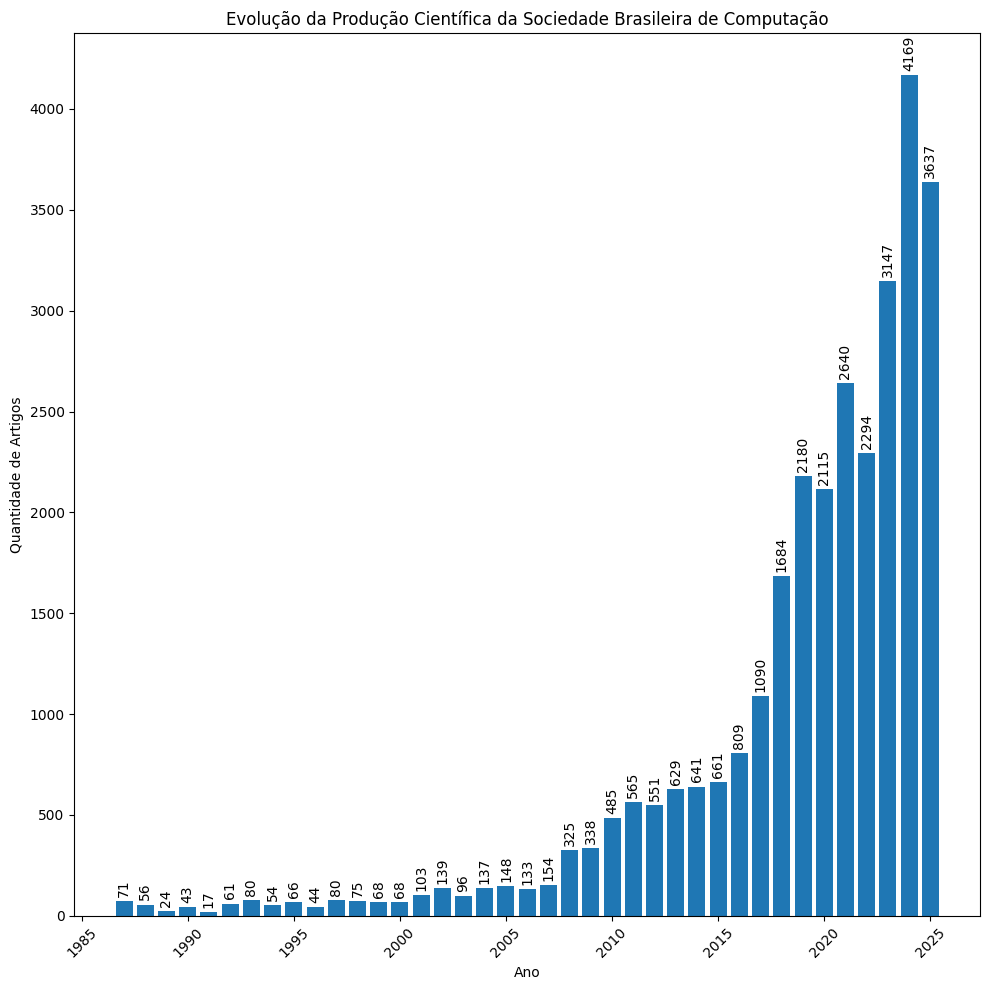

In [11]:
year_counts = df.groupby('Year')['Abstract'].count()

plt.figure(figsize=(10, 10))

plt.bar(year_counts.index, year_counts.values)

plt.xlabel("Ano")
plt.ylabel("Quantidade de Artigos")
plt.title("Evolução da Produção Científica da Sociedade Brasileira de Computação")

plt.xticks(rotation=45)

# Adiciona a quantidade acima de cada barra
for i, valor in enumerate(year_counts.values):
    plt.text(
        year_counts.index[i],
        valor + 20,
        str(valor),
        ha='center',
        va='bottom',
        rotation=90
    )

plt.tight_layout()
plt.show()

# Análise dos Resumos em Português

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
df__merged_portuguese = pd.read_csv("metadados_completos_sol_sbc_portugues.csv")

df__merged_portuguese['Date'] = pd.to_datetime(df__merged_portuguese['Date'])
df__merged_portuguese['Year'] = df__merged_portuguese['Date'].dt.year

Análise Estatística dos Resumos

In [7]:
# Tamanho Mínimo (palavras) de um Resumo por ano
# Tamanho Máximo (palavras) de um Resumo por ano
# Média de Palavras de um Resumo por ano
# Armazenar em um DataFrame e exportar para CSV

resultados = []

for year in sorted(df__merged_portuguese['Year'].unique()):
    abstracts_year = df__merged_portuguese[df__merged_portuguese['Year'] == year]['Abstract']
    word_counts = abstracts_year.apply(lambda x: len(str(x).split()))
    
    min_words = word_counts.min()
    max_words = word_counts.max()
    avg_words = word_counts.mean()
    
        # Armazena os resultados
    resultados.append({
        'Year': year,
        'Min_Words': min_words,
        'Max_Words': max_words,
        'Avg_Words': round(avg_words, 2)
    })

    print(
        f"Ano: {year} - "
        f"Mínimo: {min_words} palavras, "
        f"Máximo: {max_words} palavras, "
        f"Média: {avg_words:.2f} palavras"
    )

    print(f"Ano: {year} - Mínimo: {min_words} palavras, Máximo: {max_words} palavras, Média: {avg_words:.2f} palavras")


Ano: 1987 - Mínimo: 5 palavras, Máximo: 143 palavras, Média: 53.87 palavras
Ano: 1987 - Mínimo: 5 palavras, Máximo: 143 palavras, Média: 53.87 palavras
Ano: 1988 - Mínimo: 18 palavras, Máximo: 157 palavras, Média: 68.93 palavras
Ano: 1988 - Mínimo: 18 palavras, Máximo: 157 palavras, Média: 68.93 palavras
Ano: 1989 - Mínimo: 30 palavras, Máximo: 161 palavras, Média: 74.08 palavras
Ano: 1989 - Mínimo: 30 palavras, Máximo: 161 palavras, Média: 74.08 palavras
Ano: 1990 - Mínimo: 5 palavras, Máximo: 148 palavras, Média: 81.93 palavras
Ano: 1990 - Mínimo: 5 palavras, Máximo: 148 palavras, Média: 81.93 palavras
Ano: 1991 - Mínimo: 24 palavras, Máximo: 159 palavras, Média: 92.13 palavras
Ano: 1991 - Mínimo: 24 palavras, Máximo: 159 palavras, Média: 92.13 palavras
Ano: 1992 - Mínimo: 5 palavras, Máximo: 225 palavras, Média: 99.13 palavras
Ano: 1992 - Mínimo: 5 palavras, Máximo: 225 palavras, Média: 99.13 palavras
Ano: 1993 - Mínimo: 32 palavras, Máximo: 202 palavras, Média: 94.25 palavras
Ano: 

In [10]:
df_est_resumos = pd.DataFrame(resultados)

df_est_resumos.head(40)

,Year,Min_Words,Max_Words,Avg_Words
0,1987,5,143,53.87
1,1988,18,157,68.93
2,1989,30,161,74.08
3,1990,5,148,81.93
4,1991,24,159,92.13
5,1992,5,225,99.13
6,1993,32,202,94.25
7,1994,43,182,92.71
8,1995,48,191,105.76
9,1996,74,193,124.00


In [ ]:
recorte_anos = [2020, 2021, 2022, 2023, 2024, 2025]

artigos_2020_2025 = df__merged_portuguese[df__merged_portuguese['Year'].isin(recorte_anos)]
artigos_2020_2025.info()
artigos_2020_2025.to_csv("metadados_completos_sol_sbc_portugues_2020_2025.csv", index=False)

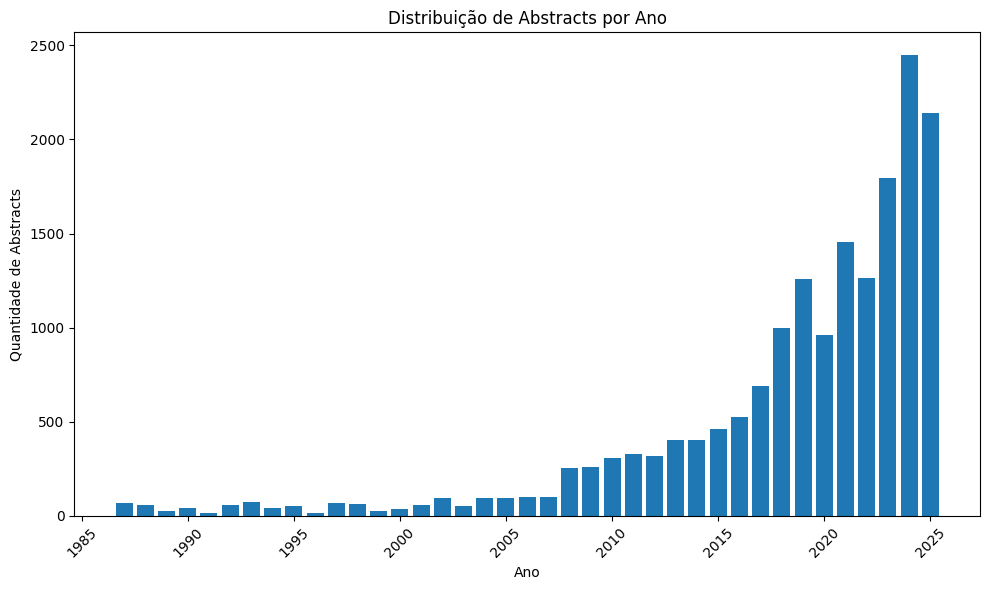

In [ ]:
year_counts = df__merged_portuguese.groupby('Year')['Abstract'].count()

plt.figure(figsize=(10, 6))
plt.bar(year_counts.index, year_counts.values)

plt.xlabel("Ano")
plt.ylabel("Quantidade de Artigos")
plt.title("Evolução da Produção Científica da Sociedade Brasileira de Computação")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()